# M2 — Exploratory Data Analysis: Hillstrom Email Campaign

**Goal of this notebook:** understand the customers and the campaign *before* we test
or model anything. We profile the data, visualise it, and form the hypotheses that the
statistical readout (M3) will test properly.

Throughout, we keep two things separate:

- **Observation** — what the data literally shows.
- **Conclusion** — what we *infer* (which may carry assumptions).

Mixing these is how analysts accidentally claim causation. Every insight below is split
this way on purpose.

> All logic lives in tested modules under `src/mdip/`. This notebook imports them and
> adds the narrative — the way a working data scientist keeps reusable code separate
> from analysis.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from mdip.config import load_config
from mdip.data.load import load_hillstrom
from mdip.eda import profile, plots
from mdip.viz.style import set_style

set_style()
pd.set_option("display.width", 120)

cfg = load_config()
df = load_hillstrom(cfg)
print(f"{df.shape[0]:,} customers x {df.shape[1]} columns")
df.head()

64,000 customers x 13 columns


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0,1
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0,1
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,1


## 1. What is one row?

One row = one past customer who was randomly assigned to receive the men's email, the
women's email, or no email, and then observed for 14 days (did they `visit`, `convert`,
and how much did they `spend`). We analyse **any email vs no email** using the binary
`treatment` column (1 = emailed, 0 = control).

In [2]:
df.dtypes

recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object

## 2. Numeric features

`recency` (months since last purchase) and `history` (prior-year spend, $).

In [3]:
profile.numeric_summary(df).round(2)

,count,mean,std,min,median,max,skew
recency,64000.0,5.76,3.51,1.00,6.00,12.00,0.14
history,64000.0,242.09,256.16,29.99,158.11,3345.93,2.42


**Observation:** `history` has a mean of \$242 but a median of \$158 and a skew of ~2.4,
with a max of \$3,346 — the average is dragged up by a small number of big spenders.
`recency` is roughly uniform (skew ~0.1).

**Conclusion:** `history` is right-skewed, so when we use it later (matching in M5,
features in M4) a **log transform** will behave better, and we should report the
**median**, not just the mean, when describing typical spend. `recency` needs no
special handling.

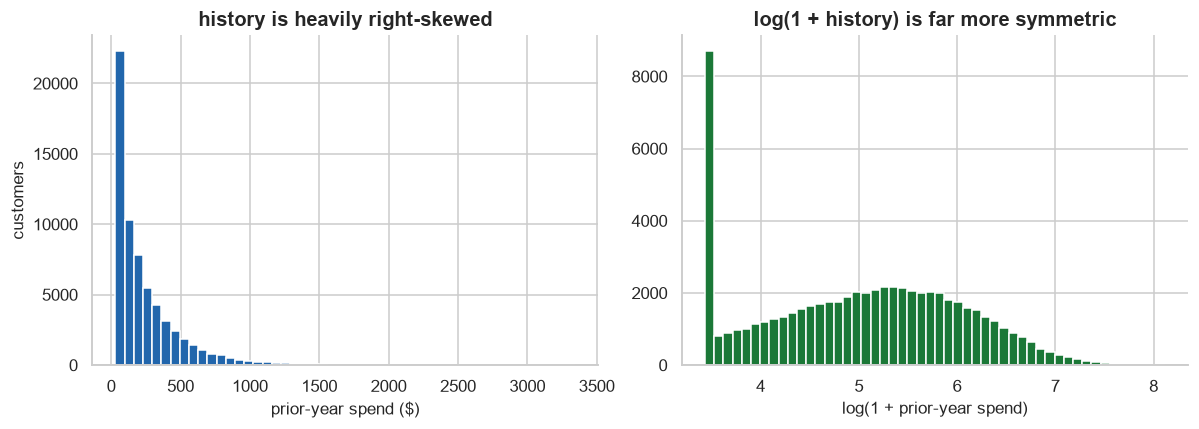

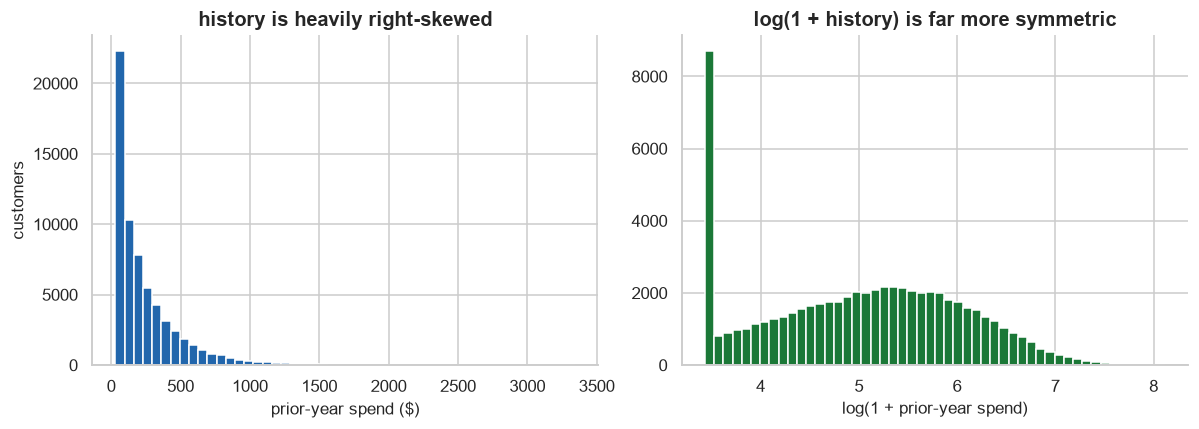

In [4]:
plots.plot_history_distribution(df)

The right panel confirms `log(1 + history)` is far more symmetric — the standard fix
for a skewed positive variable.

## 3. Customer mix (categorical features)

In [5]:
for col in ["channel", "zip_code", "history_segment", "newbie"]:
    display(profile.categorical_summary(df, col))

,channel,customers,share_pct
0,Web,28217,44.09
1,Phone,28021,43.78
2,Multichannel,7762,12.13


,zip_code,customers,share_pct
0,Surburban,28776,44.96
1,Urban,25661,40.10
2,Rural,9563,14.94


,history_segment,customers,share_pct
0,1) $0 - $100,22970,35.89
1,2) $100 - $200,14254,22.27
2,3) $200 - $350,12289,19.20
3,4) $350 - $500,6409,10.01
4,5) $500 - $750,4911,7.67
5,"6) $750 - $1,000",1859,2.90
6,"7) $1,000 +",1308,2.04


,newbie,customers,share_pct
0,1,32144,50.22
1,0,31856,49.78


**Observation:** customers split roughly evenly across Web and Phone channels (~44% each)
with ~12% Multichannel; ~50% are new customers (`newbie`); suburban and urban zips
dominate.

**Conclusion:** no category is so rare that we'd worry about tiny-sample estimates —
every subgroup we might target in M6 has thousands of customers behind it.

## 4. Did the campaign work? (raw rates)

In [6]:
profile.outcome_base_rates(df).round(4)

,outcome,treated,control,difference
0,visit,0.1670,0.1062,0.0609
1,conversion,0.0107,0.0057,0.0050
2,spend,1.2496,0.6528,0.5968


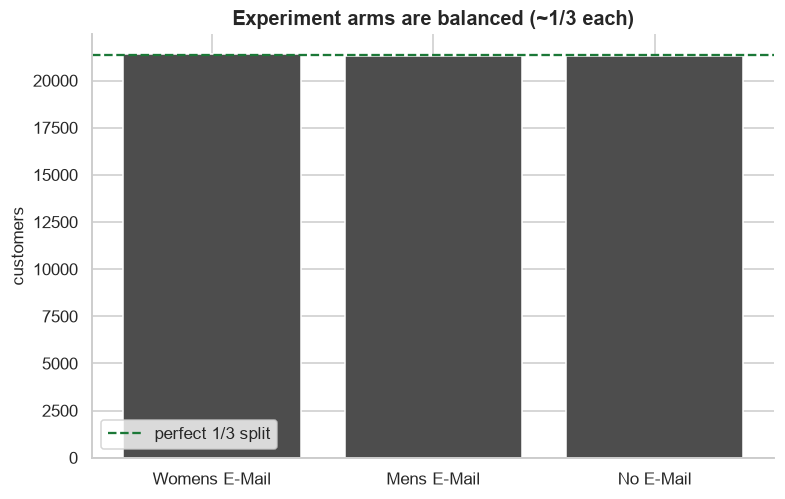

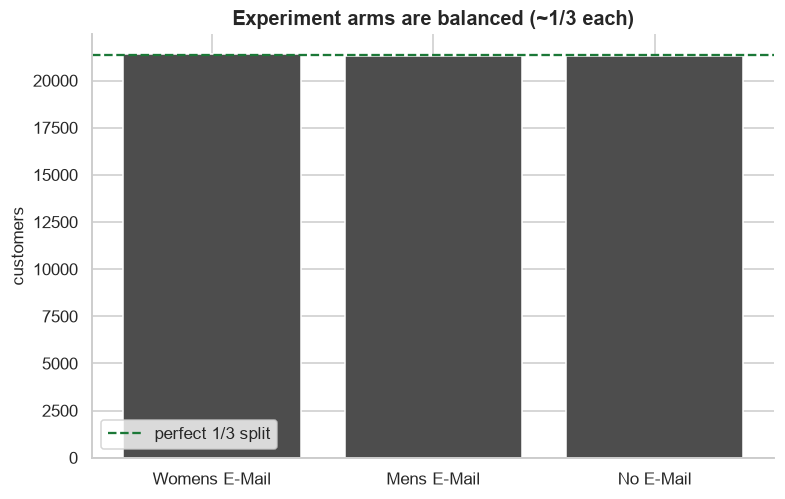

In [7]:
plots.plot_arm_sizes(df)

**Observation:** the three arms are almost exactly 1/3 each.

**Conclusion:** randomisation looks intact (no Sample Ratio Mismatch), so a simple
treated-vs-control comparison is a fair one. This is the property that will let a plain
difference in means act as an unbiased causal effect in M3.

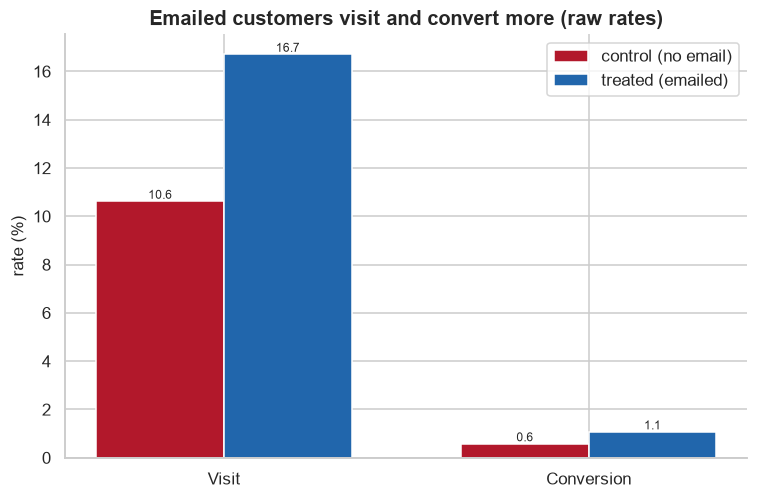

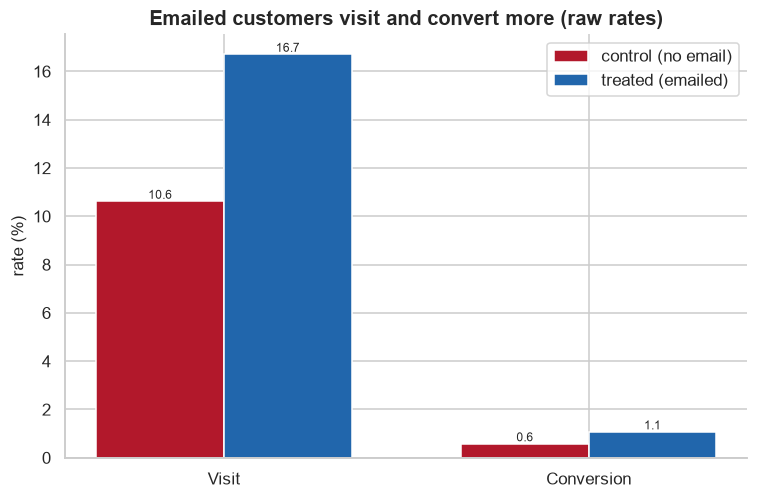

In [8]:
plots.plot_response_by_arm(df)

**Observation:** emailed customers visit at **16.7%** vs **10.6%** for control (+6.1 pp),
and convert at **1.07%** vs **0.57%** (+0.50 pp).

**Conclusion:** email is associated with a clear lift in visits and a smaller lift in
conversions. Because this is a balanced RCT, this is very likely a *causal* effect — but
we deliberately withhold that word until M3 attaches a **confidence interval** (is +6.1 pp
beyond noise?) and M5 confirms it with matching. The conversion signal is small and rare,
so we expect its uncertainty to be wide.

## 5. Does the lift differ across customers? (heterogeneity — descriptive only)

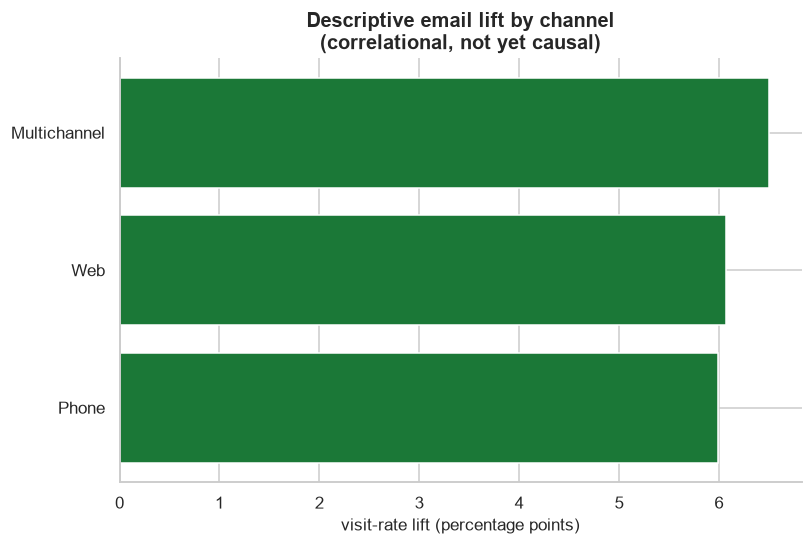

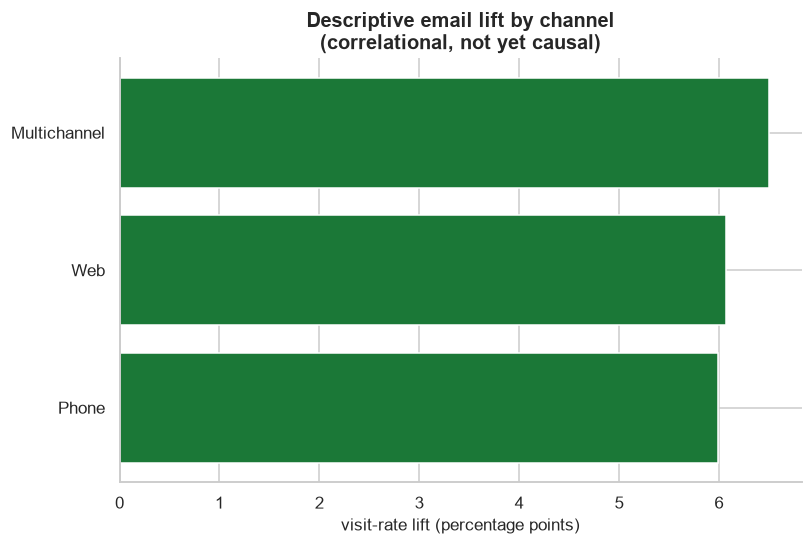

In [9]:
plots.plot_lift_by_attribute(df, by="channel")

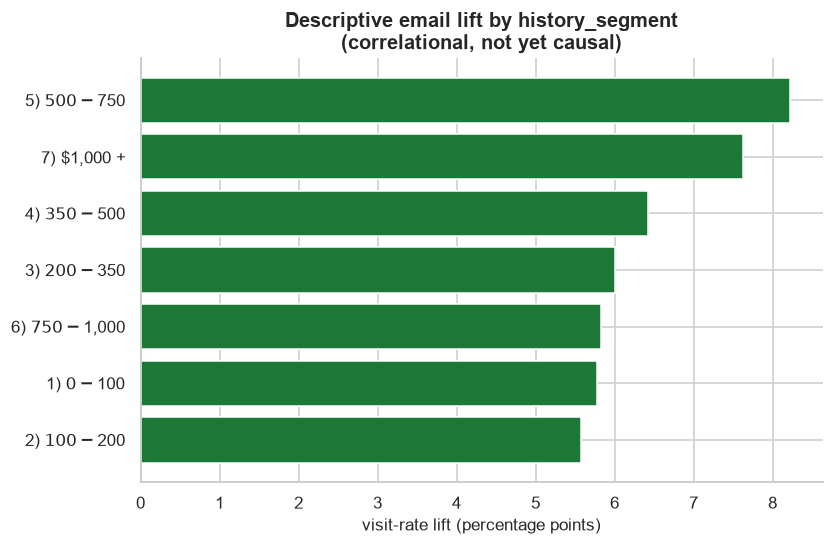

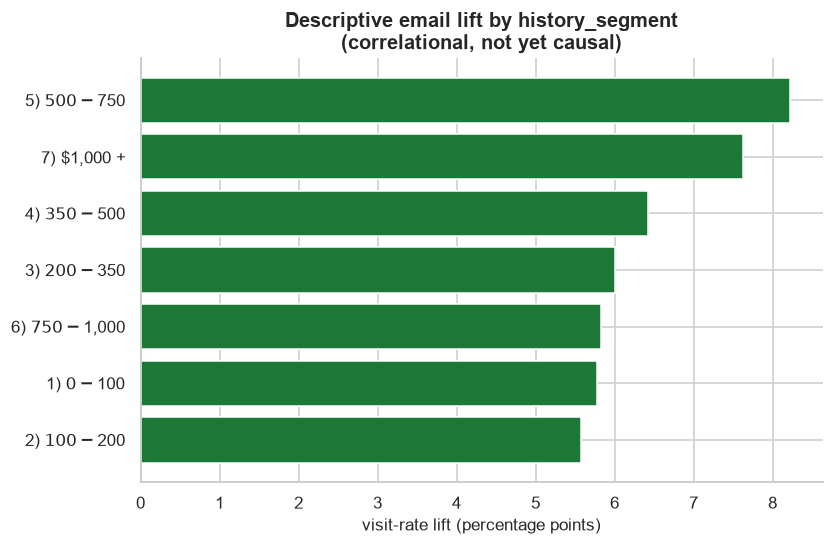

In [10]:
plots.plot_lift_by_attribute(df, by="history_segment")

In [11]:
profile.response_rate_by(df, by="channel").round(4)

,channel,customers,control_rate,treated_rate,lift
0,Multichannel,7762,0.1285,0.1936,0.0650
1,Phone,28021,0.0872,0.1471,0.0599
2,Web,28217,0.1189,0.1796,0.0607


**Observation:** the descriptive visit-rate lift is broadly similar across channels
(~6 pp) and across most attributes, with some variation by `history_segment` and
customer type (e.g. non-men's-category buyers and newbies show slightly larger raw lift).

**Conclusion (carefully hedged):** there are *hints* that email lift is not identical for
everyone — the seed of the "who to target" question. But these are **correlational**
subgroup gaps, not causal subgroup effects: a group can differ because of *who is in it*,
not because email works differently on them. We estimate proper subgroup effects and
individual uplift in M6. For now this only tells us heterogeneity is worth investigating.

## 6. How do the features relate to each other?

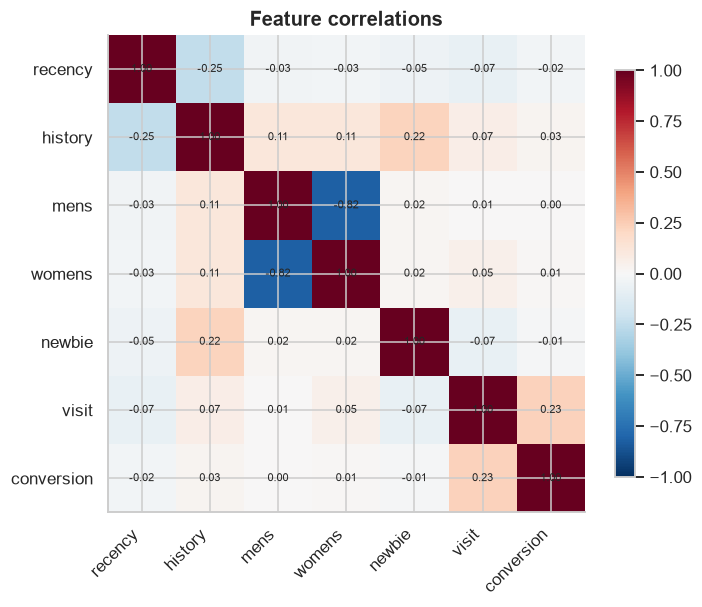

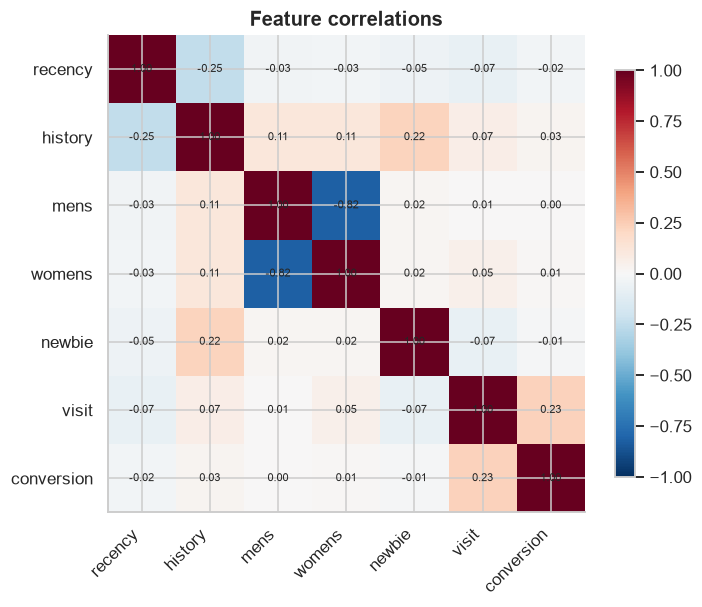

In [12]:
plots.plot_correlation_heatmap(df)

**Observation:** correlations among features are weak; `visit` and `conversion` are
positively related to each other (a visit is a step toward converting), and `mens`/
`womens` category flags are mildly negatively correlated.

**Conclusion:** no two features are near-duplicates, so we don't need to drop any for
redundancy. The `visit → conversion` link is a reminder that **`visit` is a step on the
path to `conversion`** — so when we later study the effect of email on `conversion`, we
must *not* control for `visit` (that would be conditioning on a mediator). We flag this
now and enforce it in the causal milestone.

## 7. EDA summary → hypotheses for M3

**What the data shows (observations):**
- Balanced RCT (~1/3 per arm); no missing data; clean categories.
- Raw lift: visits +6.1 pp, conversions +0.50 pp; spend heavily zero-inflated (99% zero).
- `history` is right-skewed (log-transform candidate).
- Descriptive lift is fairly stable across customer attributes, with mild variation.

**What we will now test (hypotheses for M3):**
1. Is the +6.1 pp visit lift statistically significant, and what is its confidence interval?
2. Is the small +0.50 pp conversion lift distinguishable from zero, or too noisy to call?
3. What lift could this sample size even have detected (power / MDE)?

**What we deliberately are *not* concluding yet:**
- That email *causes* the lift (M3 test + M5 matching).
- That any subgroup is a better target (M6 subgroup effects + uplift model).